In [1]:
import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
from cooling import get_t_cool_n, get_t_cool_cgs, load_cooling_table
import astropy.units as u
import astropy.constants as C
from flow_props import vel_evolution, mass_evolution
from stratified_box import StratifiedBox
import os
import latexify
#os.environ["OPENBLAS_NUM_THREADS"] = "1"
# Load cooling table
load_cooling_table("/viper/ptmp/ferhi/cooling_tables/gnat-sternberg.cooling_1Z")

# Unit conversions
pc   = 3.086e18
Myr  = 3.15576e13
Msun = 1.989e33
km   = 1e5
mbar = 9.8e-25
H = 4

def strat_n(r):
    n0 = 10
    a = 0.001

    return n0 * np.exp(-a * ((1 + (r/a/H)**2)**0.5 -1))

def strat_g(r):
    g0 = 1e-8
    a = 0.001
    return g0 * r/a/H /(1 + (r/a/H)**2)**0.5 

def strat_T(r):
    return np.ones_like(r) * 1e6

In [60]:

class TurbFallingCloud(object):
    """
    Units:
    times       --> Myr
    r_cl        --> pc
    distances   --> kpc
    n           --> cm^-3
    g           --> m/s^2
    velocities  --> km/s
    masses      --> kg
    Integration all done in SI!

    """
    def __init__(self, d0, r_cl0, T_cl = 1e4, vturb = 15, profile = 'MW', Lambda_units=None, v0 = 0):
        print("This is initial height:", d0)
        self.d0 = d0 #kpc
        self.r_cl0 = r_cl0 #pc
        self.T_cl = T_cl
        self.vturb = vturb * 1e3
        self.v0 = v0 * 1e3
        if profile == 'MW':
            self.profile_n = strat_n     # cm^-3
            self.profile_g = strat_g     # (same units used elsewhere)
            self.profile_T = strat_T      # K
            
        self.mass0 = 4/3. * (r_cl0 * u.parsec.to('cm') )**3 * np.pi * self.chi(d0) * self.profile_n(d0) * mbar / u.M_sun.to('g')
        if Lambda_units == None:  
            self.Lambda_units = 1
            self.tcool0 = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0), mbar) / u.Myr.to('s')
        else:
            self.Lambda_units = Lambda_units
            self.tcool0 = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0), mbar) / u.Myr.to('s') * Lambda_units
        print("This is Tcool0:", self.tcool0)
        Lturb = r_cl0
        f_A = 0.23
       # if self.vturb / 1000 > 30: f_A *= 2
        self.tgrow0 = 20 * (f_A / 0.23)  * (self.chi(d0)/100.) * (self.r_cl0 / 100.) *\
            (Lturb / 100.)**(-0.25) * (self.tcool0 / 0.03 )**(0.25) * (1 + self.vturb/150e3)**(-3/2.)
        #assert self.tcool0 < (r_cl0 / vturb), f"tgrow0 has to be smaller than tcc: {r_cl0 / vturb} Myr!"
        print("This is gtgrow0:", self.tgrow0 * u.Myr.to('s') * self.profile_g(d0) / 1e2 /1e3)


    def chi(self, d):
        return self.profile_T(d) / self.T_cl

    def rcl(self, d, rfirst = None):
        if rfirst == None: return self.r_cl0* (self.profile_P(self.d0) / self.profile_P(d))**(1/3.)
        else: return rfirst* (self.profile_P(self.d0) / self.profile_P(d))**(1/3.)
        

    def profile_P(self, d):
        return self.profile_T(d) * self.profile_n(d)


    def integrate(self,stop_value, vnot=1, f_KH = 0.7, alpha = 5/6., f_T = 1, verbose = 1, stop_mode = 'time', drag_bool = True):
        """
        Parameters:
            stop_value  -- Depends on `stop_mode` what it can be
            stop_mode   -- Can be:
                             'time' for stopping time in Myr
                             'height' for falling until height (in kpc) above disk
                             'tgrow_over_tcc' for falling until this value is rached
            f_KH        -- 1 for stratified and 5 for constant background recommended
            alpha       -- how does area change with mass change
        """
        def _odefun(t, y, vnot=vnot):
            """
            ODE system for cloud evolution.
            y = (z, v, m)
            """

            # Unpack state variables
            z, v, m = y

            # Position
            z_kpc = z / u.kpc.to("m")

            # Density and gravity
            rho_h = (
                self.profile_n(z_kpc)
                * mbar
                * u.g.to("kg")
                / (u.cm.to("m") ** 3)
            )
            g = -self.profile_g(z_kpc) * 1e-2  # cm/s^2 -> m/s^2

            # Cloud geometry
            C0 = 0.6  # drag coefficient
            rcl_pc = self.rcl(z_kpc)
            rcl_m = rcl_pc * u.pc.to("m")
            Across = np.pi * rcl_m**2

            # Kelvin–Helmholtz timescale factor
            r_pc_to_kpc = u.pc.to("kpc")
            v_tot = np.sqrt(v**2 + self.vturb**2)

            w_KH = (
                f_KH
                * np.sqrt(self.chi(z_kpc))
                * (self.r_cl0 * r_pc_to_kpc)
                / (t * v_tot / u.kpc.to("m"))
            )


            # Cooling time
            tcool_cl = (
                get_t_cool_n(
                    self.T_cl,
                    self.profile_n(z_kpc) * self.chi(z_kpc),
                    mbar
                )
                / u.Myr.to("s")
                * self.Lambda_units
            )


            tcoolrat = tcool_cl / self.tcool0
            mrat = m / (self.mass0 * u.Msun.to("kg"))
            rhorat = self.profile_n(z_kpc) / self.profile_n(self.d0)


            vrat = 150. / np.minimum(abs(v_tot)/1000., 150.) 


            tgrow_infall = (
                w_KH
                * self.tgrow0
                * u.Myr.to("s")
                * vrat**(3/5.)                * tcoolrat ** (1.0 / 4.0)
                * (mrat / rhorat) ** (1 - alpha)
            )

            tgrow = tgrow_infall


            

            


            def drag(self, rho_h, v, m, vnot):
                turb_drag = 0.5 * rho_h * Across * (vnot* self.vturb**2 + v**2 * C0)
                expr = turb_drag / m
                return expr
        
            vterm = g - v / tgrow 
            

            dzdt = min(0,v)
            dvdt = min(0,vterm) if v >= 0 else vterm
            dmdt = m / tgrow
            r = [dzdt, dvdt, dmdt]

            return np.array(r) 
        
        y0 = (self.d0 * u.kpc.to('m'), self.v0, self.mass0 * u.M_sun.to('kg'))

        tol = (1e-5 * u.kpc.to('m'), 1e-5 * 1e-5, 1e-5 * self.mass0* u.M_sun.to('kg'))
        o = dict(first_step = 1e-5 * u.Myr.to('s'), atol = tol, max_step = 1 * u.Myr.to('s'))
        if stop_mode == 'tgrow_over_tcc': # integrate until value of t_grow / t_cc is reached
            def _odestop(t, y): 
                return self.tgrow_over_tcc(y[0] / u.kpc.to('m')) + stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        elif stop_mode == 'time':
            tend = stop_value * u.Myr.to('s')
        elif stop_mode == 'mass':
            def _odestop(t, y): 
                return y[2] / (self.mass0 * u.Msun.to('kg')) - stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        elif stop_mode == 'height':
            def _odestop(t, y): 
                return y[0] / u.kpc.to('m') - stop_value
            _odestop.terminal = True
            tend = 1e4 * u.Myr.to('s')
            o['events'] = (_odestop,)
        else:
            raise ValueError("Unknown `stop_mode`")
        r = scipy.integrate.solve_ivp(_odefun, (0,tend),y0, **o, dense_output=True)
        if verbose > 0:
            print(r['message'])

        self.integration_result = r
        return r
    
    def vTgrow(self, t, z,v,m, alpha=5/6, f_KH= 1, Lambda_units = 1):
        z_kpc = z / u.kpc.to('m')
        v_tot = np.sqrt(v**2 + self.vturb**2)
        w_KH = np.minimum(1, f_KH* np.sqrt(self.chi(z_kpc)) *
            (self.r_cl0 * u.parsec.to('m')) /
            abs(v_tot * t))


        tcool_cl = get_t_cool_n( self.T_cl, self.profile_n(z_kpc) * self.chi(z_kpc), mbar) / u.Myr.to('s') * Lambda_units
        vrat = 150. / np.minimum(abs(v_tot)/1000., 150.) 
        tcoolrat = tcool_cl / self.tcool0
        mrat = m  / (self.mass0 * u.M_sun.to('kg'))
        print("This is initial mrat: ", mrat[0])
        rhorat = self.profile_n(z_kpc) / self.profile_n(self.d0)

        tgrow =  w_KH * self.tgrow0 * u.Myr.to('s') * vrat**(3/5.) * tcoolrat**(1/4.) * (mrat / rhorat)**(1-alpha)
        print("this is g: " , self.profile_g)
        return self.profile_g(z_kpc) * tgrow / 1e2
    
    def vTdrag(self, z,m):
        z_kpc = z / u.kpc.to('m')
        rcl = self.rcl(z_kpc) * u.pc.to('m')  # Also fix: use z_kpc
        rho_h = self.profile_n(z_kpc) * mbar * u.g.to('kg') / (u.cm.to('m')**3)  # Convert to kg/m³
        #return np.sqrt(2 * m * self.profile_g(z_kpc) * 1e-2 / (rho_h * np.pi * rcl**2 * 0.6)) - self.vturb / np.sqrt(0.6)
        return np.maximum(np.ones_like(z) * np.sqrt(2 * m * self.profile_g(z_kpc) * 1e-2 / (rho_h * np.pi * (self.r_cl0 * u.pc.to('m'))**2 * 0.6)) -  self.vturb, 0)

        #return np.ones_like(z) * rho_h * self.vturb**2 * np.pi * self.r_cl0**2 

    def plot_trajectory(self):
        assert self.integration_result is not None, "Have to run integrate first."
        r = self.integration_result
        Myr = u.Myr.to('s')


        plt.plot(r['t'] / Myr, r['y'][0] / u.kpc.to('m'),'-')
        plt.xlabel("t")
        plt.ylabel("z")
        plt.figure()
        plt.plot(r['t'] / Myr, -r['y'][1] / 1e3)
        plt.plot(r['t'] / Myr, self.vTgrow(r['y'][0], r['y'][1], r['y'][2])/1e3, color='red')
        plt.plot(r['t'] / Myr, self.vTdrag(r['y'][0],  r['y'][2])/1e3, color='black')
        plt.plot(r['t'] / Myr, 1e-8/1e5 * r['t'], color='green')
        #plt.yscale('log')
        plt.ylim(-10,100)
        plt.xlabel("t")
        plt.ylabel("v")
        plt.figure()
        plt.plot(r['t'] / Myr, r['y'][2] / r['y'][2][0])
        plt.xlabel("t")
        plt.yscale('log')
        plt.ylabel("Mass (Msun)")


    def plot_timescales(self):
        r = self.integration_result
        time = r['t'][::-1] / u.Myr.to('s')
        plt.plot(time, self.vTgrow(r['y'][0], r['y'][1], r['y'][2]))
        plt.axhline(4, c='black', alpha = 0.5)
        plt.xlabel("t (Myr)")
        plt.ylabel("tgrow / tcc")


In [66]:

class CompareRuns(object):

    def __init__(self, r_cl0, rundir, h0=None, T_cl = 1e4, vturb = 15, profile = 'MW', Lambda_units = None, v0 = 0.):

        self.rundir = rundir
        self.sim = StratifiedBox(os.path.join(self.rundir, 'strat.in'), dir=self.rundir)
        print("this is sim m_h:", self.sim.mu_H)
        print('this is sim mu_val:', self.sim.mu)
        if h0 is None:
            d0 = self.sim.y_centre / 1e3  #kpc
        else:
            d0 = h0
        self.cloud = TurbFallingCloud(d0, r_cl0, T_cl, vturb=vturb, profile=profile, Lambda_units=Lambda_units, v0 = v0)
        self.rundir = rundir
                # Load simulation


    def compare_plots(self, item, stop_mode='time', drag_bool = True, f_KH = 0.7, vnot=1):
        
        r = self.cloud.integrate(item, stop_mode=stop_mode, drag_bool=drag_bool, f_KH=f_KH, vnot=vnot)


        times, norm_mass = mass_evolution(self.rundir)
        tvs, vel = vel_evolution(self.rundir)
        mask = ~np.isnan(norm_mass)
        try:
            mask = 10**norm_mass > 1
            idx0 = np.where(mask)[0][0]
        except:
            mask = 10**norm_mass > 0   
            idx0 = np.where(mask)[0][0]

        timeseries = times[idx0:] - times[idx0]
        norm_mass = norm_mass[idx0:]- norm_mass[idx0]
        vel = vel[idx0:] 

        timeseries = timeseries  * self.sim.code_time_cgs / u.Myr.to('s')
        norm_mass = 10**norm_mass

        a = np.gradient(
            vel * self.sim.code_length_cgs / self.sim.code_time_cgs / 1e2,
            timeseries * u.Myr.to('s')
        )
        tau = self.cloud.r_cl0 * u.pc.to('m') / (self.cloud.vturb)
        dt_Myr = np.mean(np.diff(timeseries))
        window_size = int(np.round(tau / dt_Myr))
        window_size = max(100, 1)

        kernel = np.ones(window_size) / window_size
        a_smooth = np.convolve(a, kernel, mode='same')

        # Plot with integrated results
        plt.style.use('custom_plot')
        Myr = u.Myr.to('s')
        print("This is vtgrow: " , self.cloud.vTgrow(r['t'],r['y'][0], r['y'][1], r['y'][2], f_KH = f_KH, Lambda_units = self.cloud.Lambda_units)/1e3)
        plt.plot(r['t'] / Myr, -r['y'][1] / 1e3)
        plt.ylim(-10,100)
        plt.plot(r['t'] / Myr, self.cloud.vTgrow(r['t'], r['y'][0], r['y'][1], r['y'][2], f_KH = f_KH, Lambda_units = self.cloud.Lambda_units)/1e3, color='red')
        plt.plot(r['t'] / Myr, self.cloud.vTdrag(r['y'][0],  r['y'][2])/1e3, color='black')
        plt.plot(r['t'] / Myr, 1e-8/1e5 * r['t'], color='green')
        plt.plot(timeseries, vel * self.sim.code_length_cgs / self.sim.code_time_cgs / 1e5, alpha = 0.8, label='sim')
        #plt.yscale('log')
        plt.figure()
        plt.plot(r['t'] / Myr, r['y'][2] / r['y'][2][0])
        plt.scatter(timeseries, norm_mass, alpha=0.8, label='sim', color='orange')
        plt.xlabel("t")
        plt.yscale('log')
        plt.ylabel("m / m0")


this is tff:,  44.25286237443971
this is sim m_h: 1.3157894736842106
this is sim mu_val: 0.5882352941176471
This is initial height: 22.56
This is Tcool0: 0.0016408768179999491
This is gtgrow0: 17.18404908093376
A termination event occurred.
This is initial mrat:  1.0
this is g:  <function strat_g at 0x1534135c6a20>
This is vtgrow:  [27.14697456 27.14697456 27.14697456 27.14697455 27.14697427 27.14694632
 27.14433919 27.13922113 27.13612434 27.1417874  27.16440444 27.21277216
 27.29546067 27.42011502 27.59295828 27.81852497 28.09961415 28.43742176
 28.79083263 27.14222952 25.77911241 24.64376113 23.69175914 22.88860854
 22.20731923 21.62664573 21.12977135 20.70331184 20.33655345 20.02086664
 19.74925316 19.51599556 19.31638543 19.14651273 19.00310208 18.88338556
 18.78500363 18.7059277  18.64439944 18.59888306 18.56802752 18.55063646
 18.54564411 18.55209589 18.56913257 18.59597739 18.63192532 18.67633417
 18.72861716 18.78823655 18.85469831 18.92754746 19.0063641  19.09075994
 19.18037

/tmp/ipykernel_2293245/2263554619.py:98: RuntimeWarning: divide by zero encountered in scalar divide
  f_KH
/tmp/ipykernel_2293245/2263554619.py:192: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.minimum(1, f_KH* np.sqrt(self.chi(z_kpc)) *


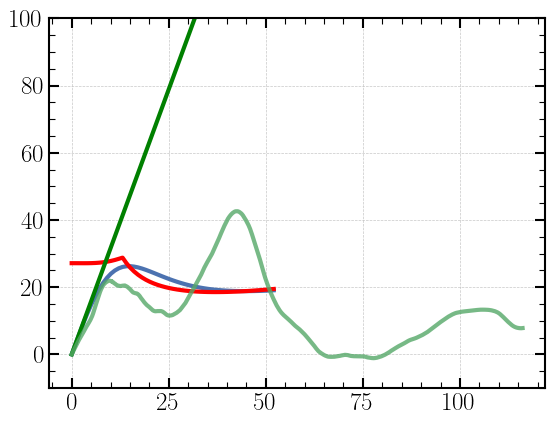

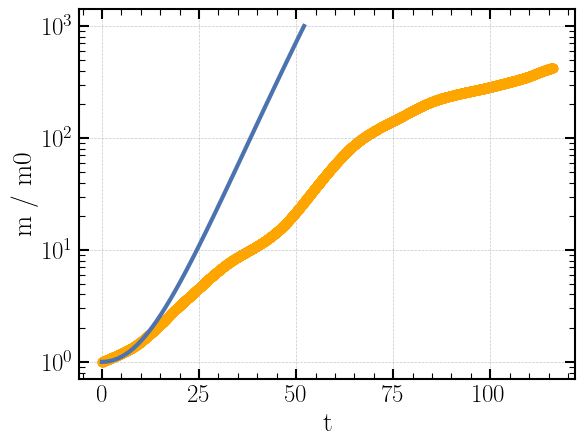

In [67]:
fc = CompareRuns(r_cl0=100, vturb=70, rundir='/viper/ptmp/ferhi/StratDisk/m0.5/r100/burnin')
fc.compare_plots(1e3, stop_mode='mass', f_KH=1, vnot=50)

this is tff:,  44.25286237443971
this is sim m_h: 1.3157894736842106
this is sim mu_val: 0.5882352941176471
This is initial height: 22.56
This is Tcool0: 0.0016408768179999491
This is gtgrow0: 26.456574300386265
A termination event occurred.
This is initial mrat:  1.0
this is g:  <function strat_g at 0x1534135c6a20>
This is vtgrow:  [105.32551937 105.32551937 105.32551936 105.32551763 105.32534473
 105.3080578  103.63814582  99.72147228  94.5106408   88.87562937
  83.36996451  78.26377441  73.6514086   69.53784386  65.88957143
  62.66044475  59.80351493  57.27581041  55.03979188  53.0633417
  51.31917687  49.78409458  48.43823024  47.26439908  46.24754324
  45.3742842   44.63257102  44.01141194  43.50067575  43.09094987
  42.77344314  42.53992203  42.38267117  42.29446978  42.26857789
  42.29872726  42.37911355  42.50438748  42.66964345  42.87040538
  43.10260941  43.36258394  43.64702758  43.95298547  44.27782475
  44.61920965  44.9750767   45.34361064  45.7232211   46.11252052
  46.5

/tmp/ipykernel_2293245/2263554619.py:98: RuntimeWarning: divide by zero encountered in scalar divide
  f_KH
/tmp/ipykernel_2293245/2263554619.py:192: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.minimum(1, f_KH* np.sqrt(self.chi(z_kpc)) *


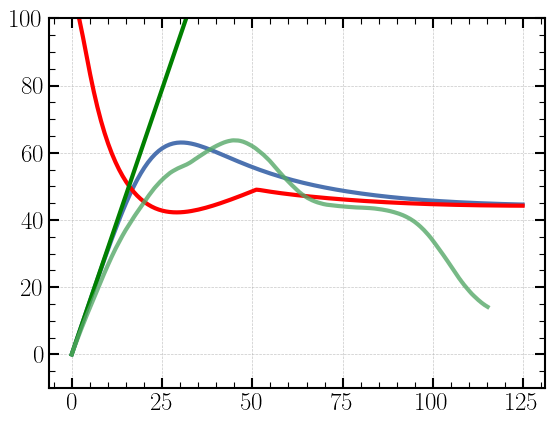

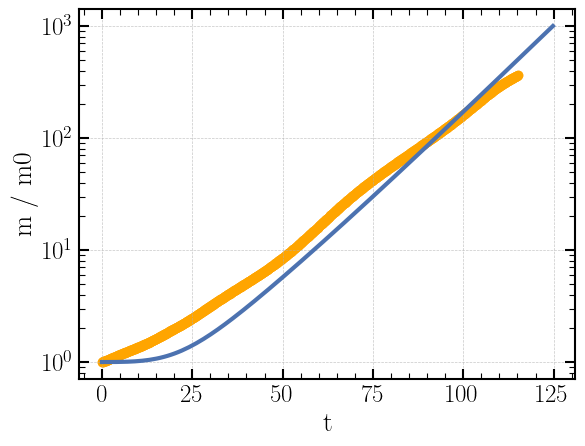

In [68]:
fc = CompareRuns(r_cl0=100, vturb=15, rundir='/viper/ptmp/ferhi/StratDisk/m0.1/r100/burnin')
fc.compare_plots(1e3, stop_mode='mass', f_KH=3)

this is sim m_h: 1.3157894736842106
this is sim mu_val: 0.5882352941176471
This is initial height: 22.56
This is Tcool0: 0.0016408768179999491
This is gtgrow0: 30.492180878024133
A termination event occurred.
This is initial mrat:  1.0
this is g:  <function strat_g at 0x1534135c6a20>
This is vtgrow:  [2453.82305598 2453.82298267 2453.81418535 2452.92050358 2369.94433647
 1129.1192496   290.22298928  197.39314288  156.30099675  132.0994255
  115.78711367  103.88471681   94.73571746   87.4417086    81.46966992
   76.48185542   72.25319565   68.62759294   65.49318353   62.76755113
   60.3884814    58.30795846   56.48814067   54.89859066   53.51432749
   52.3144343    51.28105202   50.39864777   49.65348278   49.03322708
   48.52668304   48.12358936   47.814484     47.59060949   47.4438479
   47.36667544   47.35212973   47.39378405   47.4857252    47.6225324
   47.79925576   48.01139384   48.25486981   48.52600656   48.82150093
   49.13839748   49.47406219   49.82615656   50.19261227   50.

/tmp/ipykernel_2293245/2263554619.py:98: RuntimeWarning: divide by zero encountered in scalar divide
  f_KH
/tmp/ipykernel_2293245/2263554619.py:192: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.minimum(1, f_KH* np.sqrt(self.chi(z_kpc)) *


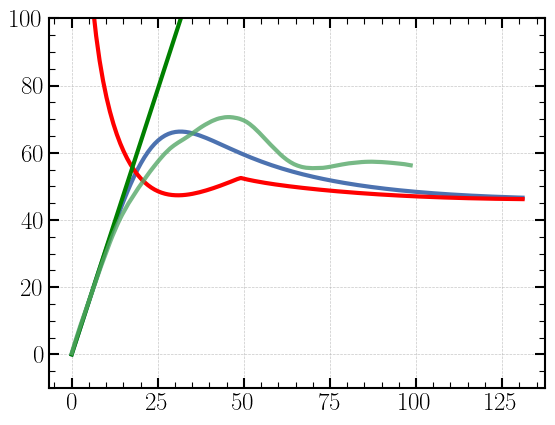

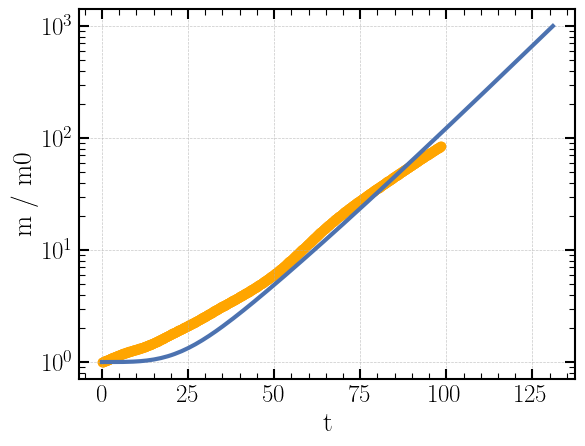

In [69]:
fc = CompareRuns(r_cl0=100, vturb=0.1, rundir='/viper/ptmp/ferhi/StratDisk/noturb/r100') 
fc.compare_plots(1e3, stop_mode='mass', f_KH=3)

this is tff:,  44.25286237443971
this is sim m_h: 1.3157894736842106
this is sim mu_val: 0.5882352941176471
This is initial height: 42.84
This is Tcool0: 0.002611854527971445
This is gtgrow0: 14.196527748088005
A termination event occurred.
This is initial mrat:  1.0
this is g:  <function strat_g at 0x1534135c6a20>
This is vtgrow:  [16.23035965 16.23035965 16.23035965 16.23035968 16.23036288 16.23068284
 16.26277883 16.34829816 16.48945373 16.68921837 16.9506834  17.27650212
 17.66855187 18.05029065 16.53255241 15.3729045  14.4734564  13.7685469
 13.21263067 12.77323277 12.42664415 12.15518837 11.9454333  11.78699248
 11.67170531 11.59306622 11.54582033 11.52567247 11.52907432 11.55306643
 11.59515913 11.65324169 11.72551192 11.81042121 11.90663093 12.01297769
 12.12844532 12.25214202 12.28385267]
This is initial mrat:  1.0
this is g:  <function strat_g at 0x1534135c6a20>


/tmp/ipykernel_2293245/2263554619.py:98: RuntimeWarning: divide by zero encountered in scalar divide
  f_KH
/tmp/ipykernel_2293245/2263554619.py:192: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.minimum(1, f_KH* np.sqrt(self.chi(z_kpc)) *


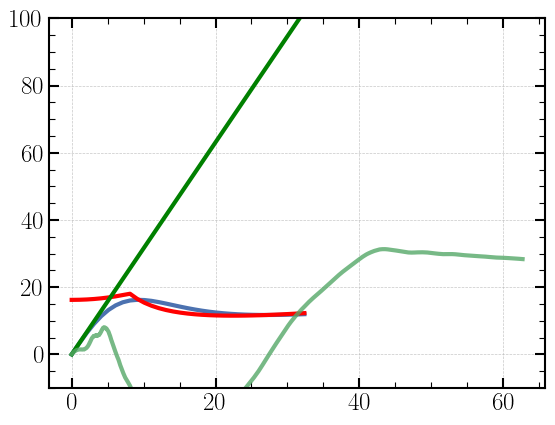

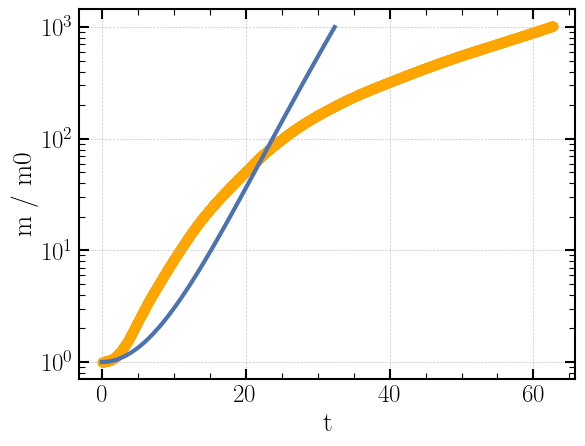

In [74]:
fc = CompareRuns(r_cl0=100, vturb=120, rundir='/viper/ptmp/ferhi/InfallTurbulent/mach_test/r1e4/m0.8', Lambda_units=0.01) 
fc.compare_plots(1e3, stop_mode='mass', f_KH=1)


this is tff:,  44.25286237443971
this is sim m_h: 1.3157894736842106
this is sim mu_val: 0.5882352941176471
This is initial height: 42.84
This is Tcool0: 0.2611854527971445
This is gtgrow0: 21.683075846348192
A termination event occurred.
This is initial mrat:  1.0
this is g:  <function strat_g at 0x14f57a3cd260>
This is vtgrow:  [ 34.25443593  34.25444465  34.25453178  34.25540321  34.26412077
  34.35163165  35.26083865  36.23404377  37.27406934  38.38353919
  39.56464581  40.81885615  42.14655464  43.54662854  45.01601038
  46.54920597  48.13785261  49.77037019  51.43178222  53.10379089
  54.76518111  56.39259954  57.96170198  59.44859415  60.83141937
  62.09189378  63.21657473  64.19768158  65.03336469  65.72741743
  66.28851982  66.72916656  67.06445542  67.3108967   67.48536342
  67.60425195  67.68287586  67.73508112  67.77304958  67.80724862
  67.84648488  67.89802494  67.96775322  68.06034515  68.17944023
  68.32780565  68.50748486  68.71992877  68.96610907  69.2466145
  69.5617

/tmp/ipykernel_3707469/2304942124.py:98: RuntimeWarning: divide by zero encountered in scalar divide
  f_KH


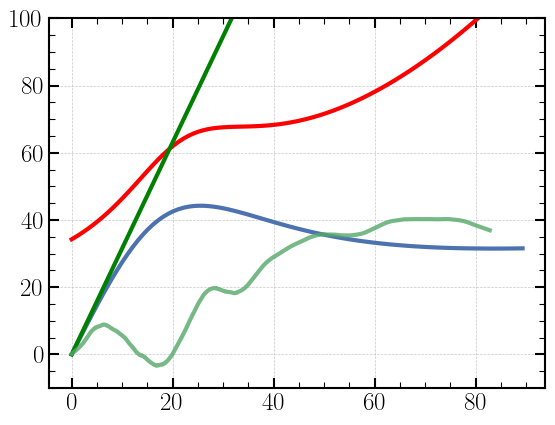

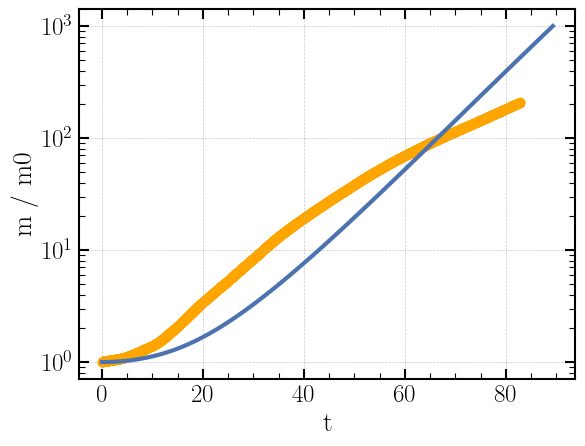

In [93]:
plt.style.use('custom_plot')
fc = CompareRuns(r_cl0=100, vturb = 70, rundir='/viper/ptmp/ferhi/InfallTurbulent/mach_test/r1e3/m0.5', cooling_factor=0.2)
fc.compare_plots(1e3, stop_mode='mass')

this is tff:,  44.25286237443971
This is initial height: 11.6
This is Tcool0: 0.00106
This is gtgrow0: 2.9196536804756867
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_3887404/1223033732.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_3887404/1223033732.py:149: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


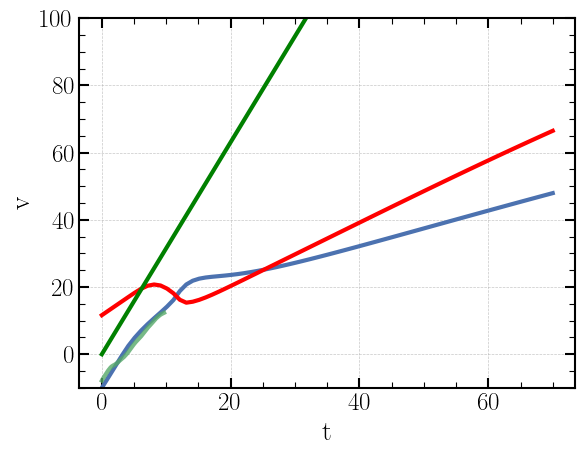

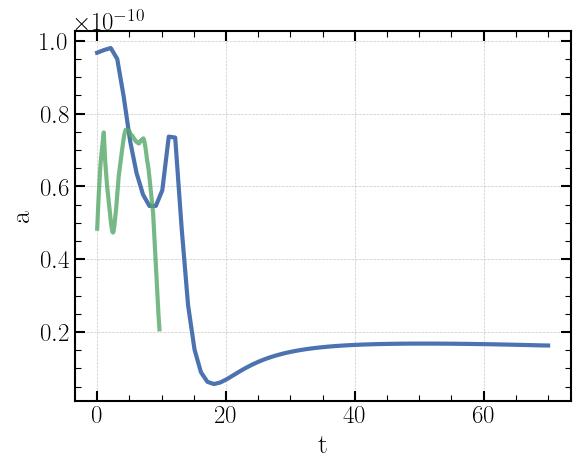

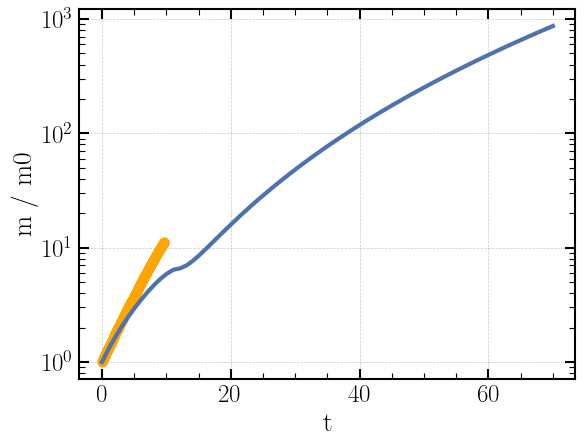

In [94]:
plt.style.use('custom_plot')
fc = CompareRuns(r_cl0=10, vturb = 15, tcool = 1.06e-3, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r10/t1e4', v0 = 10)
fc.compare_plots(70, drag_bool=True)

this is tff:,  44.25286237443971
This is initial height: 16.0
This is Tcool0: 0.000106
This is gtgrow0: 15.695684978300163
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_3887404/1223033732.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_3887404/1223033732.py:149: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


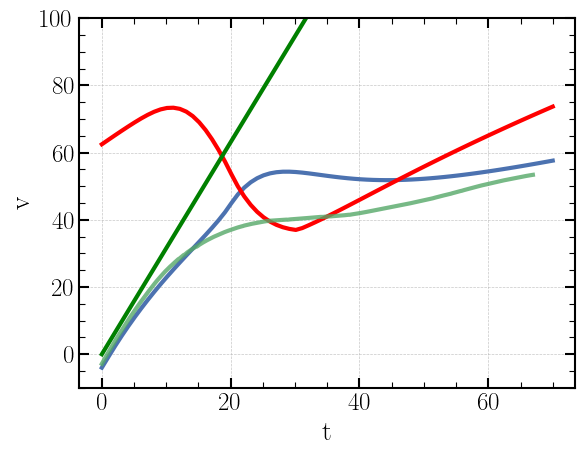

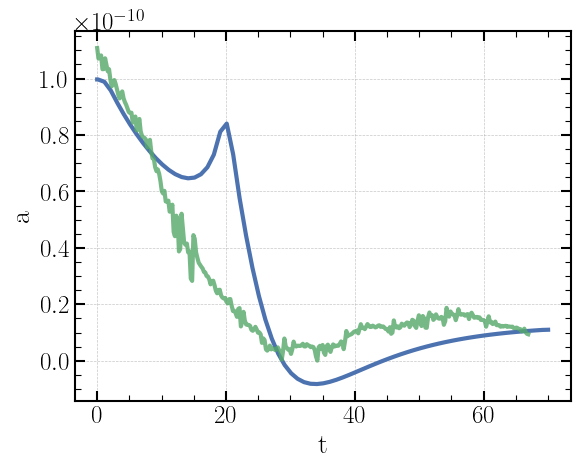

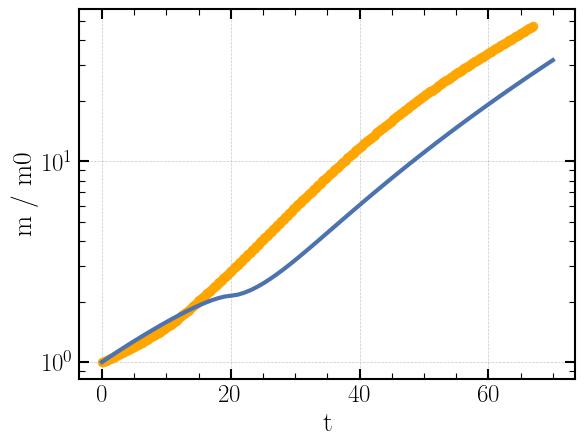

In [53]:
fc = CompareRuns(r_cl0=100, vturb = 15, tcool = 1.06e-4, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r100/t1e3', v0 = 4, cooling_factor=1.7)
fc.compare_plots(70)

this is tff:,  44.25286237443971
This is initial height: 16.0
This is Tcool0: 0.106
This is gtgrow0: 51.91960170863277
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_3887404/1223033732.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_3887404/1223033732.py:149: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


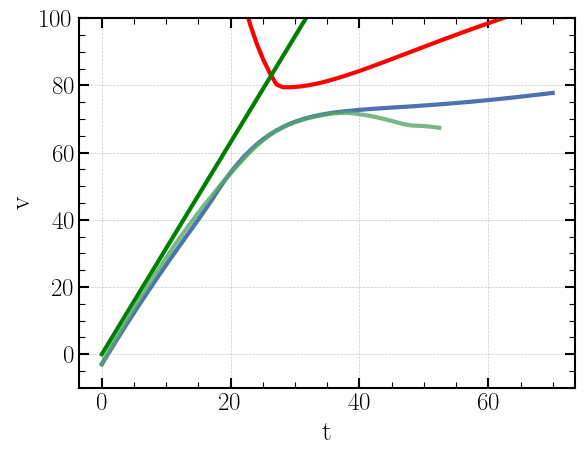

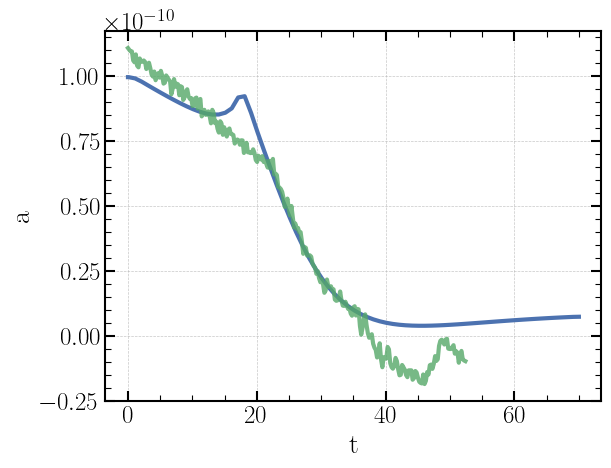

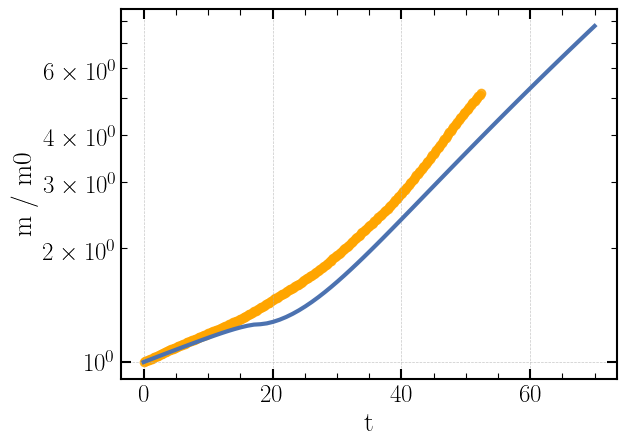

In [54]:
fc = CompareRuns(r_cl0=100, vturb = 15, tcool = 1.06e-1, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r100/t1e6', v0 = 3)
fc.compare_plots(70)

this is tff:,  44.25286237443971
This is initial height: 11.115999999997475
This is Tcool0: 1.83e-05
This is gtgrow0: 0.03346706627666172
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_3887404/1223033732.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_3887404/1223033732.py:149: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


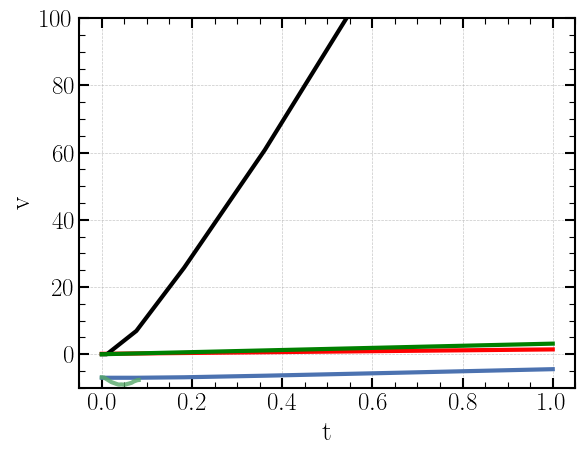

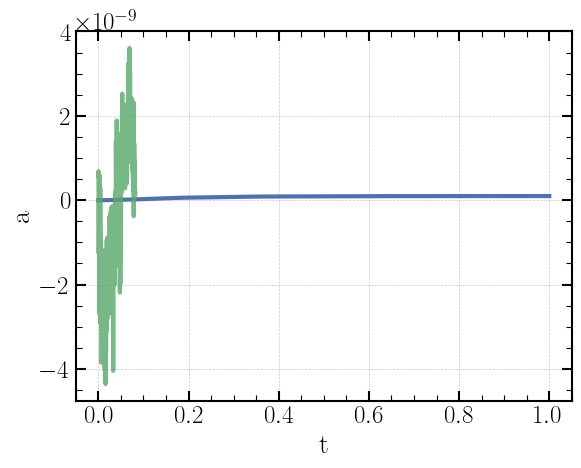

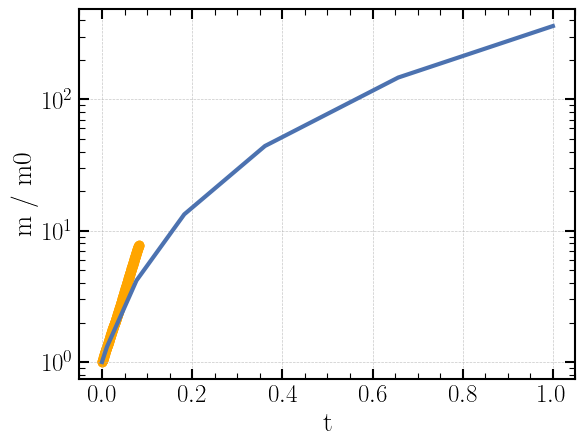

In [55]:
fc = CompareRuns(r_cl0=0.1, vturb = 17, tcool = 1.83e-5, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r0.1/t1e3', v0 = 7)
fc.compare_plots(1)


this is tff:,  44.25286237443971
This is initial height: 11.115999999997475
This is Tcool0: 0.000163
This is gtgrow0: 0.057816496659790995
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_3887404/1223033732.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_3887404/1223033732.py:149: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


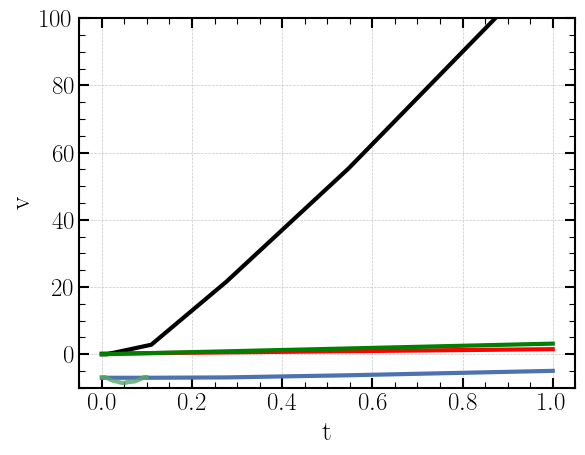

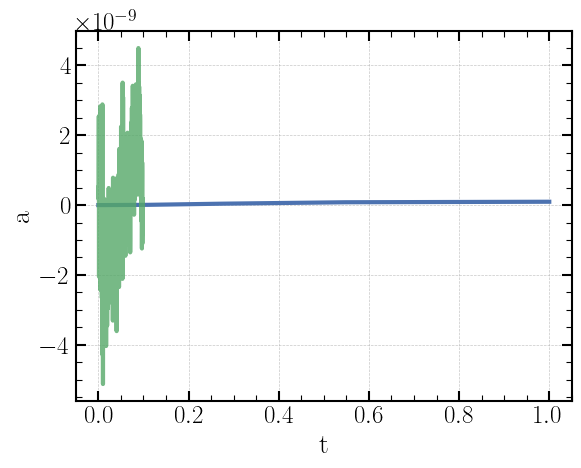

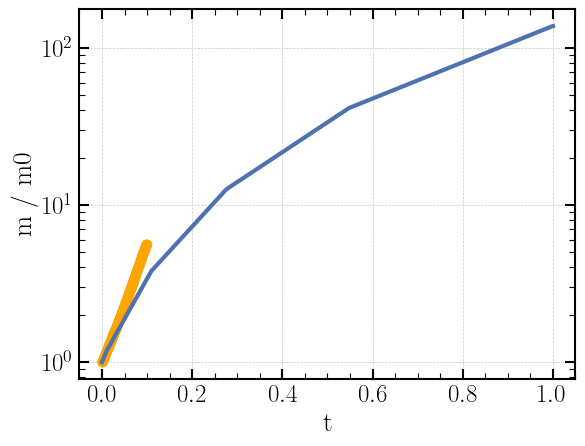

In [56]:
fc = CompareRuns(r_cl0=0.1, vturb = 20, tcool = 1.63e-4, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r0.1/t1e4', v0 = 7)
fc.compare_plots(1)


this is tff:,  44.25286237443971
This is initial height: 11.6
This is Tcool0: 1.83e-05
This is gtgrow0: 1.0583215659791196
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_3887404/1223033732.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_3887404/1223033732.py:149: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


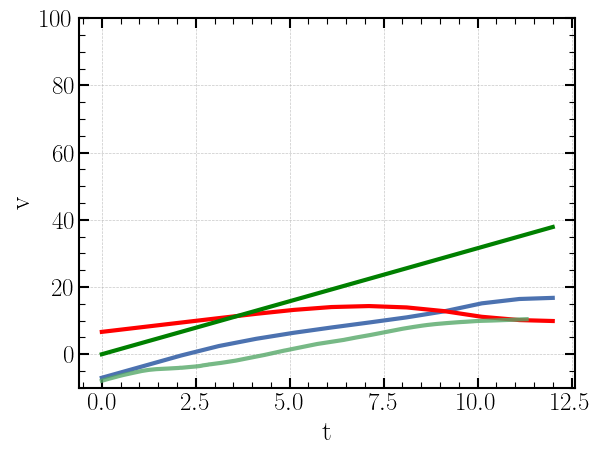

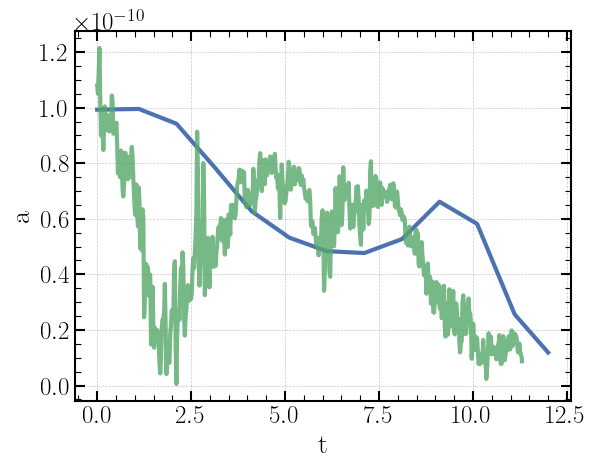

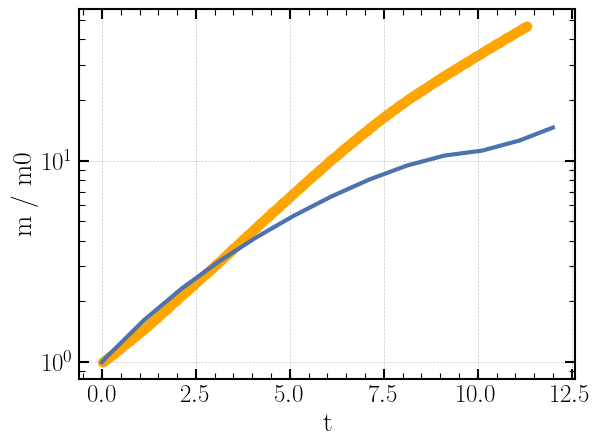

In [57]:
fc = CompareRuns(r_cl0=10, vturb =7, tcool = 1.83e-5, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r10/t1e3', v0 =7)
fc.compare_plots(12)



this is tff:,  44.25286237443971
This is Tcool0: 0.00165
This is gtgrow0: 0.5799303766478862
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_4075414/1974216344.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_4075414/1974216344.py:108: RuntimeWarning: divide by zero encountered in scalar divide
  dmdt = m / tgrow - m / (2 * self.chi(z_kpc)**0.5 * rcl_m / abs(v) * np.sqrt(1 + (abs(v)/10000)))
/tmp/ipykernel_4075414/1974216344.py:148: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


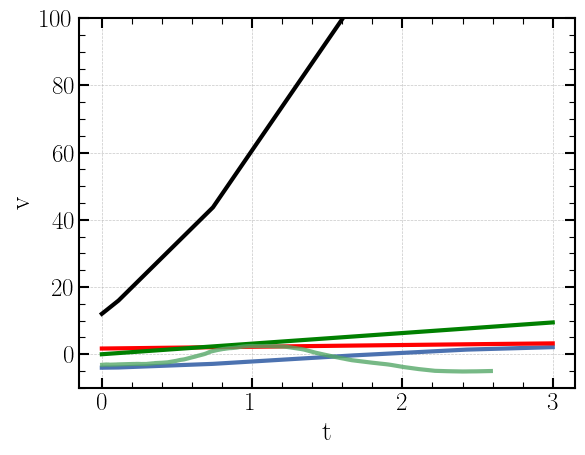

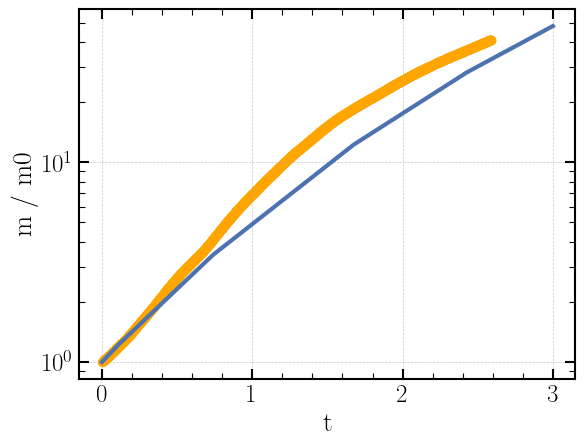

In [33]:
fc = CompareRuns(r_cl0=1, vturb =25, tcool = 1.65e-3, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/r1/t1e5_v2', v0 =4)
fc.compare_plots(3)

this is tff:,  44.25286237443971
This is Tcool0: 1.83e-06
This is gtgrow0: 1.963955241237737
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_4075414/1387966886.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_4075414/1387966886.py:148: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


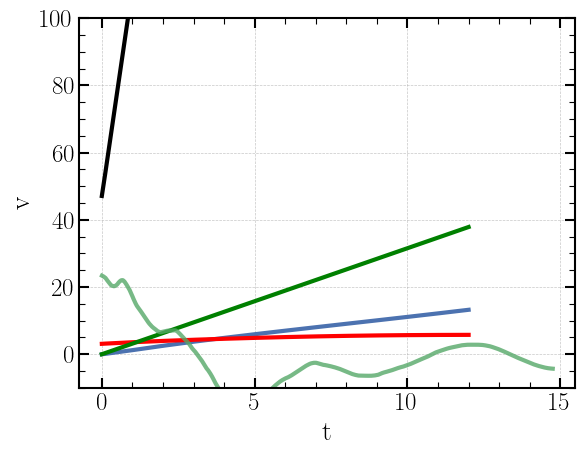

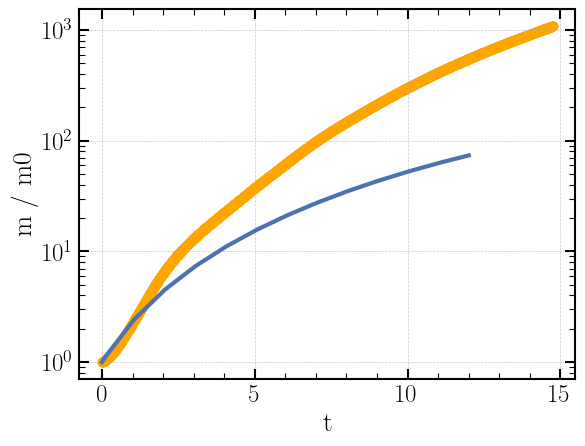

In [60]:
fc = CompareRuns(r_cl0=10, vturb =70, tcool = 1.83e-6, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.5/r10/t1e6', v0 =0)
fc.compare_plots(12)


this is tff:,  44.25286237443971
This is Tcool0: 0.00183
This is gtgrow0: 1.1044131929721612
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_4075414/1387966886.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_4075414/1387966886.py:148: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


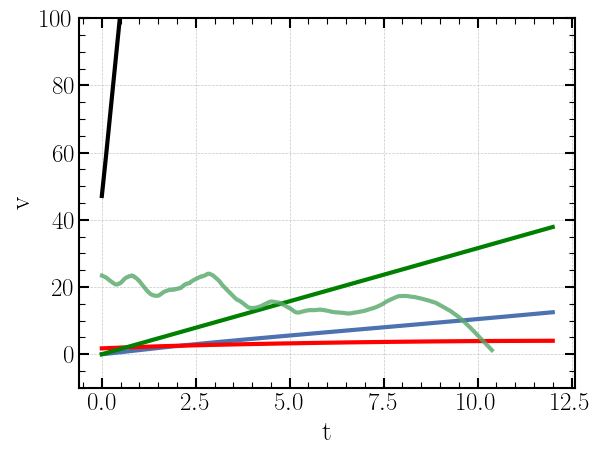

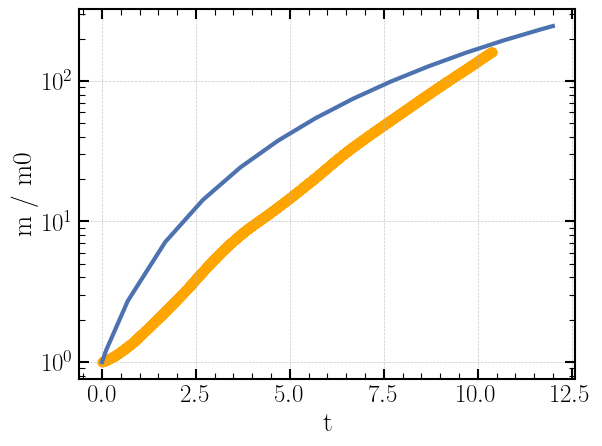

In [69]:
fc = CompareRuns(r_cl0=10, vturb =70, tcool = 1.83e-3, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.5/r10/t1e3', cooling_factor=0.1)
fc.compare_plots(12)

this is tff:,  44.25286237443971
This is Tcool0: 0.00402
This is gtgrow0: 0.2125912358922255
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_4075414/1387966886.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_4075414/1387966886.py:148: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


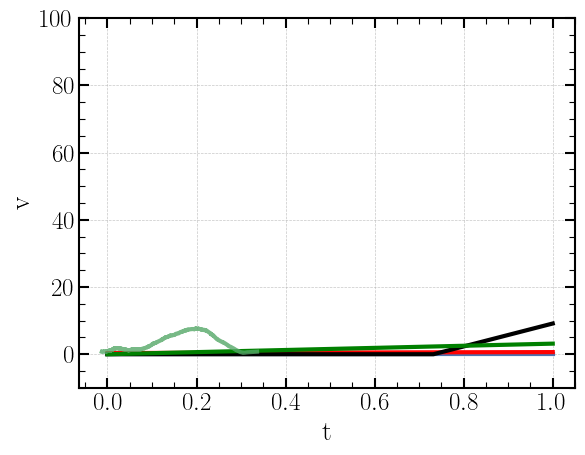

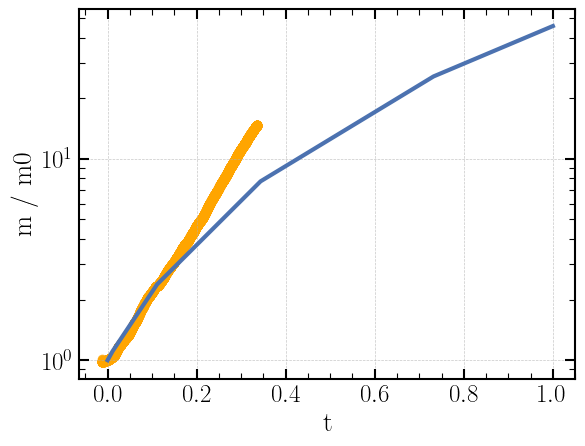

In [62]:
fc = CompareRuns(0.1, vturb =70, tcool = 4.02e-3, rundir='/viper/ptmp/ferhi/StratDisk/Rsys/m0.1/h120', cooling_factor=0.5)
fc.compare_plots(1, stop_mode='time')

This is Tcool0: 0.00402
This is gtgrow0: 0.425182471784451
The solver successfully reached the end of the integration interval.


/tmp/ipykernel_4075414/1387966886.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \
/tmp/ipykernel_4075414/1387966886.py:148: RuntimeWarning: divide by zero encountered in divide
  w_KH = np.maximum(1, f_T * np.sqrt(self.chi(z_kpc)) *


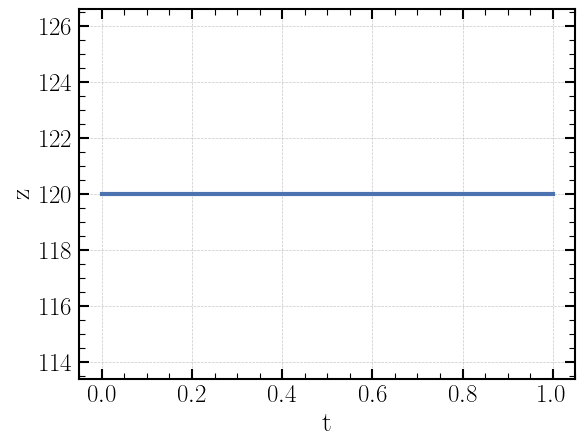

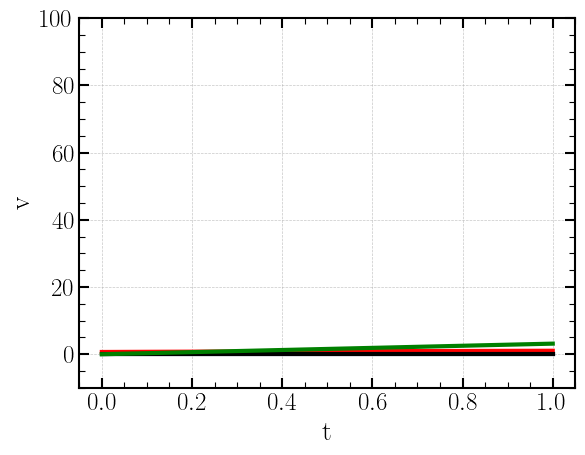

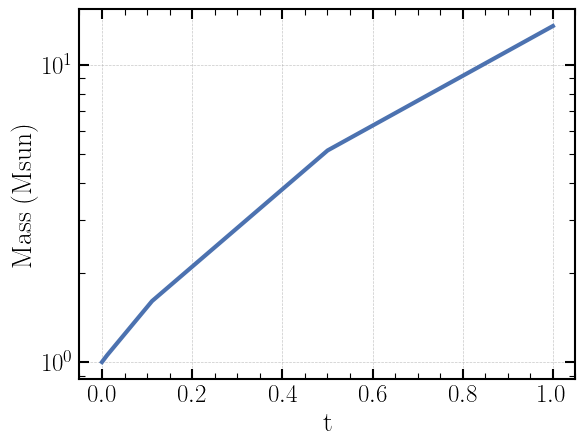

In [63]:
fc = TurbFallingCloud(120, r_cl0=0.1, vturb =70, tcool = 4.02e-3)
fc.integrate(1, stop_mode='time')
fc.plot_trajectory()

This is initial height: 40
This is Tcool0: 0.08996226996449594
This is gtgrow0: 4.596283379779641
A termination event occurred.


/tmp/ipykernel_4123426/817368187.py:98: RuntimeWarning: divide by zero encountered in scalar divide
  f_KH
/tmp/ipykernel_4123426/817368187.py:116: RuntimeWarning: divide by zero encountered in scalar divide
  vrat = 150.0 / min(abs(v_tot) / 1000.0, 150.0)
/tmp/ipykernel_4123426/817368187.py:129: RuntimeWarning: divide by zero encountered in scalar divide
  vrat2 = 150 / min(abs(v_combined), 150.0)
/tmp/ipykernel_4123426/817368187.py:133: RuntimeWarning: divide by zero encountered in scalar divide
  self.chi(z_kpc)
/tmp/ipykernel_4123426/817368187.py:223: RuntimeWarning: divide by zero encountered in divide
  vrat = 75 / np.minimum(abs(v_tot), 150.)


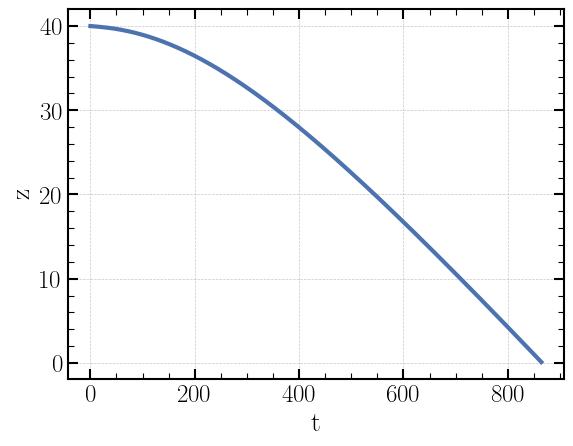

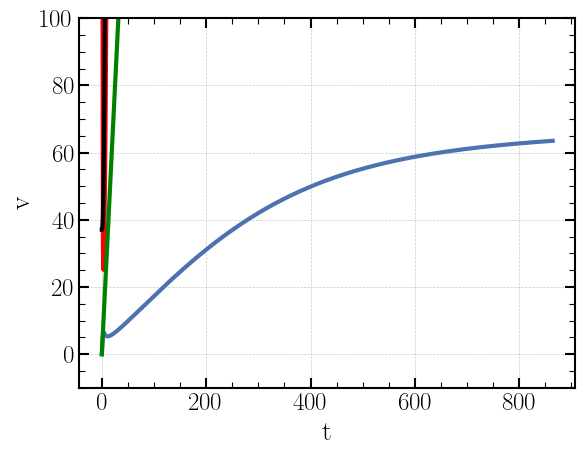

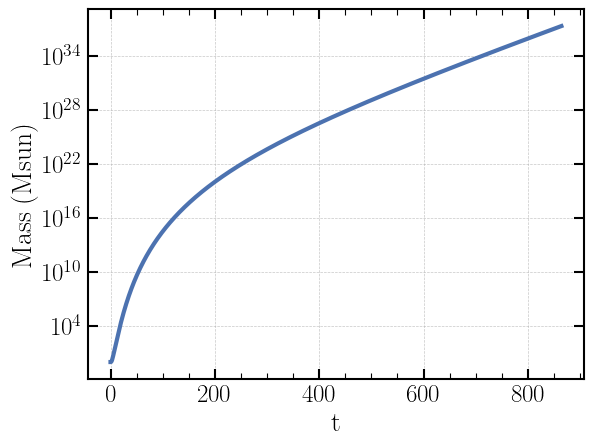

In [15]:
fc = TurbFallingCloud(40, r_cl0=1, vturb =0)
fc.integrate(0.1, stop_mode='height')
fc.plot_trajectory()

In [41]:
def in_safe_zone(h):
    pressure =  strat_n(h) * strat_T(h)
    safe_pressure = 3000*(strat_g(h)/(1e-8))**0.8 * ((strat_T(h)/1e6))**(12/5)
    return (pressure > safe_pressure)


In [12]:
def get_tgrow_over_tcc_at_vmax(r0,h,vturb):
        
    # Run model
    cloud = TurbFallingCloud(h,r0, vturb=vturb)

    def in_safe_zone(h):
        pressure =  cloud.profile_n(h) * cloud.profile_T(h)
        safe_pressure = 3000*(cloud.profile_g(h)/(1e-8))**0.8 * ((cloud.profile_T(h)/1e6))**(12/5)
        return (pressure > safe_pressure)
    

    sol = cloud.integrate(0.01, stop_mode='height')

    if len(sol.t_events[0]) > 0:
        t_end = sol.t_events[0][0]
    else:
        t_end = sol.t[-1]

    # Convert to a continuous solution
    t_range = np.linspace(0, t_end, 1000)
    solution = sol.sol(t_range)


    # compute L
    z = solution[0]
    v = -solution[1]
    m = solution[2]

    idx_vmax = np.argmax(v)

    if in_safe_zone(h):
        return 0, v[idx_vmax]
    
    
    tgrow_vmax = cloud.vTgrow(z[idx_vmax], v[idx_vmax], m[idx_vmax]) * 1e2 / cloud.profile_g(z[idx_vmax])
    tcc_vmax = np.sqrt(cloud.profile_T(z[idx_vmax])/1e4)*r0 * u.pc.to('m')/v[idx_vmax]

    return tgrow_vmax/tcc_vmax, v[idx_vmax]

In [13]:
from tqdm.notebook import tqdm
import itertools

rcllst = np.logspace(0,4,30)
d0lst  = np.logspace(-1,2,30) #70,10)

combs = list(itertools.product(rcllst,d0lst))
fclst = []
vmlst = []
for rcl, d0 in tqdm(combs):
    tt, vm = get_tgrow_over_tcc_at_vmax(rcl,d0, vturb=70)
    fclst.append(tt)
    vmlst.append(vm)

  0%|          | 0/900 [00:00<?, ?it/s]

This is initial height: 0.1
This is Tcool0: 4.187758308261587e-06
This is gtgrow0: 0.75869974433259
A termination event occurred.
This is initial height: 0.12689610031679222
This is Tcool0: 4.215993927488403e-06
This is gtgrow0: 0.7602055419678287
A termination event occurred.
This is initial height: 0.16102620275609392
This is Tcool0: 4.252106715611713e-06
This is gtgrow0: 0.7619715932856947
A termination event occurred.
This is initial height: 0.20433597178569415
This is Tcool0: 4.2983849907682235e-06
This is gtgrow0: 0.7641257329639689
A termination event occurred.
This is initial height: 0.2592943797404667
This is Tcool0: 4.357841633122744e-06
This is gtgrow0: 0.7668102060137162
A termination event occurred.
This is initial height: 0.32903445623126687
This is Tcool0: 4.434479650955315e-06
This is gtgrow0: 0.7701942477902349


/tmp/ipykernel_4123426/817368187.py:98: RuntimeWarning: divide by zero encountered in scalar divide
  f_KH


A termination event occurred.
This is initial height: 0.41753189365604015
This is Tcool0: 4.5336771910064835e-06
This is gtgrow0: 0.774487501151189
A termination event occurred.
This is initial height: 0.5298316906283709
This is Tcool0: 4.662758781593135e-06
This is gtgrow0: 0.7799559121636471
A termination event occurred.
This is initial height: 0.6723357536499337
This is Tcool0: 4.831864905233593e-06
This is gtgrow0: 0.7869419612690408
A termination event occurred.
This is initial height: 0.8531678524172808
This is Tcool0: 5.055313640233337e-06
This is gtgrow0: 0.7958916467437932
A termination event occurred.
This is initial height: 1.0826367338740546
This is Tcool0: 5.353800163019043e-06
This is gtgrow0: 0.8073916773872927
A termination event occurred.
This is initial height: 1.373823795883263
This is Tcool0: 5.758073710736285e-06
This is gtgrow0: 0.8222221225206677
A termination event occurred.
This is initial height: 1.743328822199988
This is Tcool0: 6.31532324643464e-06
This is g

In [ ]:
print("hello")

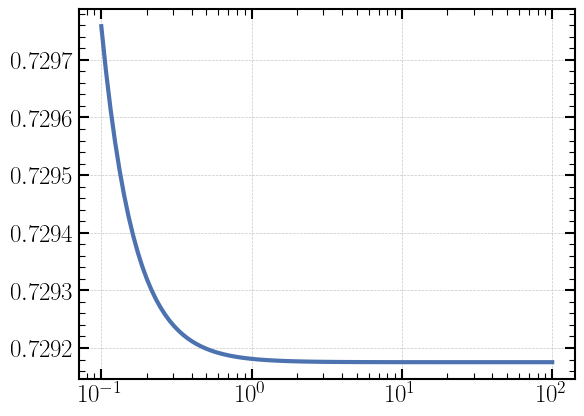

In [ ]:
vt = 15000
z = np.logspace(-1, 2, 100)
rho = strat_n(z) * mbar * u.g.to('kg') / (u.cm.to('m')**3)
g = strat_g(z) * 1e-2

rcrit = vt **2 / 100 / g /u.pc.to("m") 
plt.plot(z, rcrit)
plt.xscale('log')


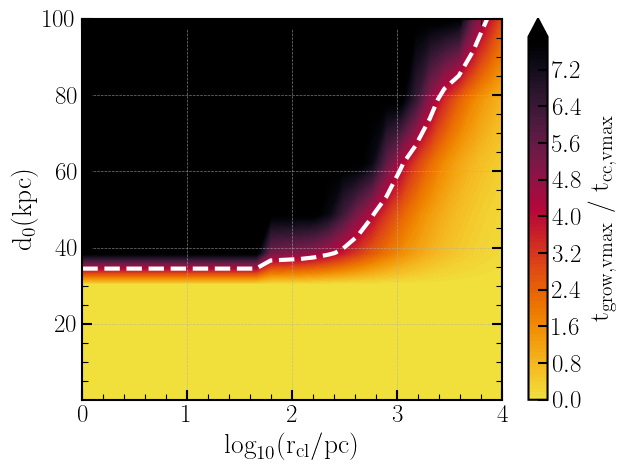

In [14]:
import cmasher as cmr
trat_arr = np.reshape(fclst,(len(d0lst),len(rcllst))).copy().T

vmax = 8
z = np.clip(trat_arr,-np.inf, vmax)

#latexify(columns=1)
plt.figure()
cnt = plt.contourf(np.log10(rcllst),d0lst,z, vmax=vmax, levels=100, extend='max', cmap='cmr.ember_r')
plt.colorbar(label=r't$_{\rm grow,vmax}$ / t$_{\rm cc,vmax}$')

plt.contour(np.log10(rcllst),d0lst,z,levels=[4],colors='white',linestyles='dashed')
plt.xlabel(r"$\log_{10}$(r$_{\rm cl}/$pc)")
plt.ylabel(r"d$_0$ (kpc)")

#plt.contour(np.log10(rcllst),np.log10(d0lst),z,levels=[4],colors='white',linestyles='dashed')
#plt.hlines(10,0,3,ls='--',color='white')

plt.xlabel(r"$\log_{10}$(r$_{\rm cl}/$pc)")
plt.ylabel(r"d$_0$(kpc)")

# survrad = [10.27665695 for i in rcllst]
# survrad = [cfc.get_survival_radius() for cfc in fclst]


# This is the fix for the white lines between contour levels
#for c in cnt.collections:
#    c.set_edgecolor("face")

# plt.ylim(5,60)

plt.tight_layout()
#plt.savefig("0.5cs_survival.png",dpi=300)

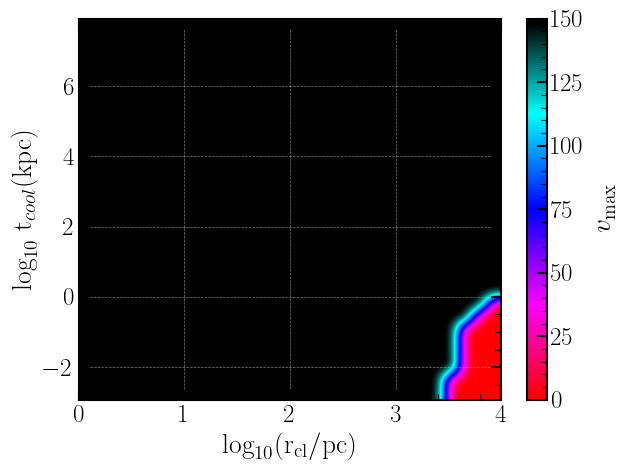

In [22]:
trat_arr = np.reshape(vmlst,(len(d0lst),len(rcllst))).copy().T
vmax = 150
z = np.clip(trat_arr, 0.1, vmax)  # Clip to positive values for log scale

x = np.log10(rcllst)
y = np.log10(get_t_cool_cgs(strat_n(d0lst) * 0.6 * C.m_p.to('g').value, 1e4, 9.8e-25)/ u.Myr.to('s'))

plt.figure()
extent = [x.min(), x.max(), y.min(), y.max()]
# Use imshow with LogNorm + interpolation to produce a continuous-looking log-colormap
cnt = plt.imshow(z.T, origin='lower', extent=extent, aspect='auto',
                 vmin=0, vmax=vmax,
                 cmap='BLUE-RED_r', interpolation='bicubic')
plt.colorbar(label=r'$v_{\rm max}$')

#plt.contour(np.log10(rcllst),np.log10(d0lst),z,levels=[4],colors='white',linestyles='dashed')
#plt.hlines(10,0,3,ls='--',color='white')

plt.xlabel(r"$\log_{10}$(r$_{\rm cl}/$pc)")
plt.ylabel(r"$\log_{10}$ t$_{cool}$(kpc)")

# survrad = [10.27665695 for i in rcllst]
# survrad = [cfc.get_survival_radius() for cfc in fclst]


# This is the fix for the white lines between contour levels
#for c in cnt.collections:
#    c.set_edgecolor("face")

# plt.ylim(5,60)

plt.tight_layout()

In [118]:
def get_v_at_m3m0(r0,h,vturb):
        
    # Run model
    cloud = TurbFallingCloud(h,r0, vturb=vturb)
    

    sol = cloud.integrate(1e3, stop_mode='mass')

    if len(sol.t_events[0]) > 0:
        t_end = sol.t_events[0][0]
    else:
        t_end = sol.t[-1]

    # Convert to a continuous solution
    t_range = np.linspace(0, t_end, 1000)
    solution = sol.sol(t_range)


    # compute L
    z = solution[0]
    v = -solution[1]
    m = solution[2]

    idx_vmax = np.argmax(v)

    return v[idx_vmax] if (v[idx_vmax] > 0) else 0

In [121]:
from tqdm.notebook import tqdm
import itertools

rcllst = np.logspace(-1,2,30)
d0lst  = np.logspace(-1,2,30) #70,10)

combs = list(itertools.product(rcllst,d0lst))
fclst = []
for rcl, d0 in tqdm(combs):
    tt = get_v_at_m3m0(rcl,d0, vturb=70)
    fclst.append(tt/1e3)


  0%|          | 0/900 [00:00<?, ?it/s]

This is Tcool0: 1.2025477349244795e-05
This is gtgrow0: 0.0993567237915767
A termination event occurred.
This is Tcool0: 1.2106558150585255e-05
This is gtgrow0: 0.09955391790011306
A termination event occurred.
This is Tcool0: 1.2210258861951092e-05
This is gtgrow0: 0.0997851939408679
A termination event occurred.
This is Tcool0: 1.2343150568848038e-05
This is gtgrow0: 0.10006729270605344
A termination event occurred.
This is Tcool0: 1.2513884993632265e-05
This is gtgrow0: 0.10041884211584567
A termination event occurred.
This is Tcool0: 1.2733957089416416e-05
This is gtgrow0: 0.1008620046535957
A termination event occurred.
This is Tcool0: 1.3018810627557041e-05
This is gtgrow0: 0.10142423443097201
A termination event occurred.
This is Tcool0: 1.3389478567190035e-05
This is gtgrow0: 0.10214035883539178
A termination event occurred.
This is Tcool0: 1.3875080101415423e-05
This is gtgrow0: 0.10305522793419394
A termination event occurred.
This is Tcool0: 1.4516730718203825e-05
This is gt

/tmp/ipykernel_4075414/3707401733.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \


A termination event occurred.
This is Tcool0: 64.83986022216195
This is gtgrow0: 4.791586756762703
A termination event occurred.
This is Tcool0: 4220.268481395871
This is gtgrow0: 13.609866301656982
A termination event occurred.
This is Tcool0: 844497.4381339032
This is gtgrow0: 51.18803085880549
A termination event occurred.
This is Tcool0: 1.2025477349244795e-05
This is gtgrow0: 0.11879098116786321
A termination event occurred.
This is Tcool0: 1.2106558150585255e-05
This is gtgrow0: 0.11902674660717757
A termination event occurred.
This is Tcool0: 1.2210258861951092e-05
This is gtgrow0: 0.11930326043284999
A termination event occurred.
This is Tcool0: 1.2343150568848038e-05
This is gtgrow0: 0.1196405379498998
A termination event occurred.
This is Tcool0: 1.2513884993632265e-05
This is gtgrow0: 0.12006085071510136
A termination event occurred.
This is Tcool0: 1.2733957089416416e-05
This is gtgrow0: 0.12059069621188524
A termination event occurred.
This is Tcool0: 1.3018810627557041e-0

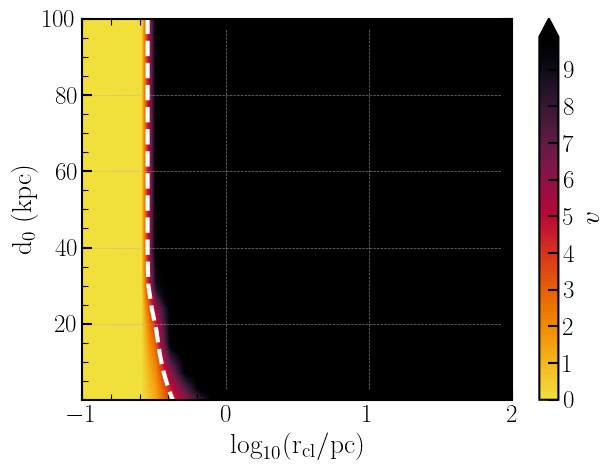

In [122]:
import cmasher as cmr
trat_arr = np.reshape(fclst,(len(d0lst),len(rcllst))).copy().T

z = np.clip(trat_arr, 0, 10)

#latexify(columns=1)
plt.figure()
cnt = plt.contourf(np.log10(rcllst),d0lst,z, levels=100, extend='max', cmap='cmr.ember_r')
plt.colorbar(label=r'$v$')

plt.contour(np.log10(rcllst),d0lst,z,levels=[4],colors='white',linestyles='dashed')
plt.xlabel(r"$\log_{10}$(r$_{\rm cl}/$pc)")
plt.ylabel(r"d$_0$ (kpc)")

# survrad = [10.27665695 for i in rcllst]
# survrad = [cfc.get_survival_radius() for cfc in fclst]


# This is the fix for the white lines between contour levels
#for c in cnt.collections:
#    c.set_edgecolor("face")

# plt.ylim(5,60)

plt.tight_layout()

In [ ]:
from tqdm.notebook import tqdm
import itertools

rcllst = np.logspace(-2,2,30)
d0lst  = np.logspace(-1,2,30) #70,10)

combs = list(itertools.product(rcllst,d0lst))
fclst = []
for rcl, d0 in tqdm(combs):
    tt = get_v_at_m3m0(rcl,d0, vturb=70)
    fclst.append(tt/1e3)
import cmasher as cmr


  0%|          | 0/900 [00:00<?, ?it/s]

This is Tcool0: 1.1759954836201036e-05
This is gtgrow0: 0.0918102686452475
A termination event occurred.
This is Tcool0: 1.1767409451342854e-05
This is gtgrow0: 0.09432320617432537
A termination event occurred.
This is Tcool0: 1.1777082935177225e-05
This is gtgrow0: 0.09600108729420492
A termination event occurred.
This is Tcool0: 1.1789542111576922e-05
This is gtgrow0: 0.09710182111862894
A termination event occurred.
This is Tcool0: 1.1805512199995189e-05
This is gtgrow0: 0.09782120024057914
A termination event occurred.
This is Tcool0: 1.1825922475883786e-05
This is gtgrow0: 0.0982973743886927
A termination event occurred.
This is Tcool0: 1.185196418755901e-05
This is gtgrow0: 0.09862398992661027
A termination event occurred.
This is Tcool0: 1.1885165265120339e-05
This is gtgrow0: 0.09886350595989284
A termination event occurred.
This is Tcool0: 1.192748778385406e-05
This is gtgrow0: 0.09905783659223662
A termination event occurred.
This is Tcool0: 1.198145628627651e-05
This is gtgr

/tmp/ipykernel_4075414/3707401733.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  w_KH = f_KH * np.sqrt(self.chi(z_kpc)) * \


This is Tcool0: 1.1767409451342854e-05
This is gtgrow0: 0.11277290334020337
A termination event occurred.
This is Tcool0: 1.1777082935177225e-05
This is gtgrow0: 0.11477897939532407
A termination event occurred.
This is Tcool0: 1.1789542111576922e-05
This is gtgrow0: 0.11609501766649612
A termination event occurred.
This is Tcool0: 1.1805512199995189e-05
This is gtgrow0: 0.11695510793987712
A termination event occurred.
This is Tcool0: 1.1825922475883786e-05
This is gtgrow0: 0.11752442214532377
A termination event occurred.
This is Tcool0: 1.185196418755901e-05
This is gtgrow0: 0.11791492395268297
A termination event occurred.
This is Tcool0: 1.1885165265120339e-05
This is gtgrow0: 0.11820128952023884
A termination event occurred.
This is Tcool0: 1.192748778385406e-05
This is gtgrow0: 0.1184336313850483
A termination event occurred.
This is Tcool0: 1.198145628627651e-05
This is gtgrow0: 0.1186466981646115
A termination event occurred.
This is Tcool0: 1.205032830826121e-05
This is gtgro

Text(0, 0.5, 'd$_0$ (kpc)')

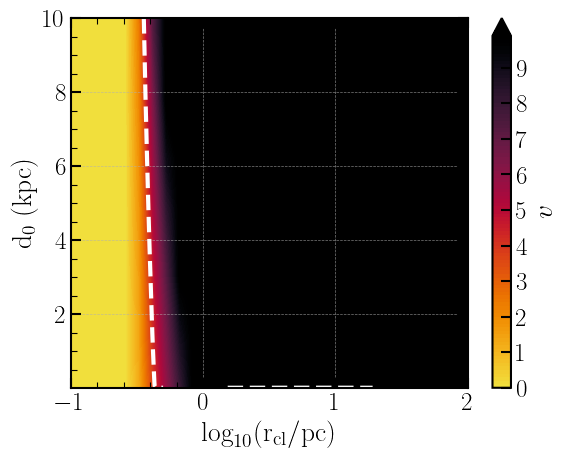

In [120]:
trat_arr = np.reshape(fclst,(len(d0lst),len(rcllst))).copy().T

z = np.clip(trat_arr, 0, 10)

#latexify(columns=1)
plt.figure()
cnt = plt.contourf(np.log10(rcllst),d0lst,z, levels=100, extend='max', cmap='cmr.ember_r')
plt.colorbar(label=r'$v$')

plt.contour(np.log10(rcllst),d0lst,z,levels=[4],colors='white',linestyles='dashed')
plt.xlabel(r"$\log_{10}$(r$_{\rm cl}/$pc)")
plt.ylabel(r"d$_0$ (kpc)")

This is Tcool0: 4.093592009700087e-05
This is gtgrow0: 0.1350656271305142
A termination event occurred.


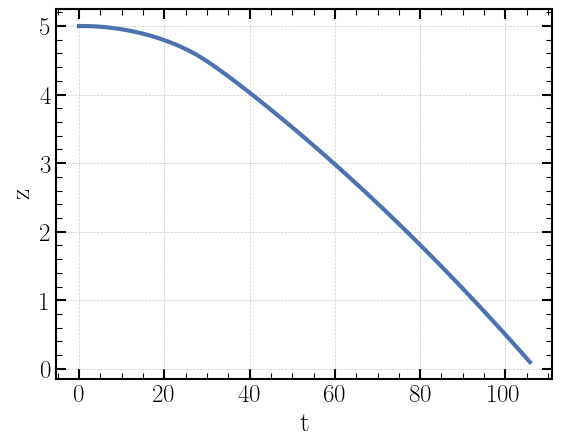

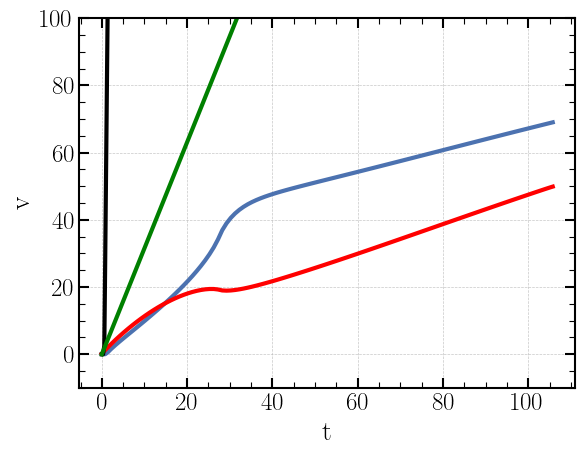

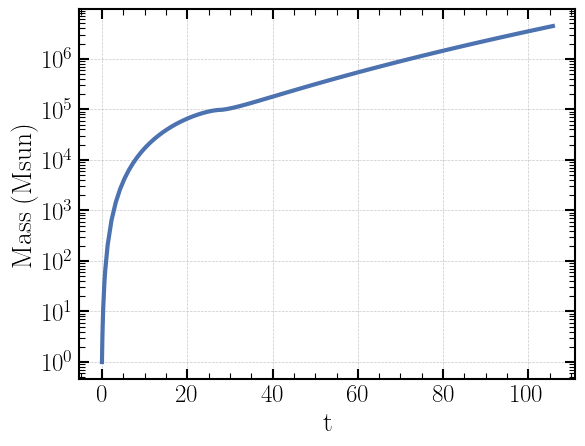

In [146]:
fc = TurbFallingCloud(5, r_cl0=0.1, vturb =70)
fc.integrate(0.1, stop_mode='height')
fc.plot_trajectory()